# HotpotQA scan store with Qwen config

This notebook mirrors the early corpus-scanning part of `hotpotqa_embeds_explore.ipynb`, but it does **not** run embedding yet.

Current scope:
- scan the full HotpotQA corpus
- extract phrase/token spans with the existing spaCy pipeline
- build an `embedding_store`-like structure without any `embedding` field
- save the scan-only store for later embedding steps


In [ ]:
from pathlib import Path
import os
import sys

REPO_ROOT = Path.cwd().resolve()
if REPO_ROOT.name == "jupyter_notebooks":
    REPO_ROOT = REPO_ROOT.parent

os.chdir(REPO_ROOT)
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

print(f"Working directory: {REPO_ROOT}")


In [1]:
from collections import defaultdict
from pathlib import Path
import json
import pickle

import matplotlib.pyplot as plt
import numpy as np
import spacy
import torch
from IPython.display import display
from sklearn.decomposition import PCA
from spacy.tokenizer import Tokenizer
from spacy.util import compile_infix_regex
from transformers import AutoModel, AutoTokenizer

from text_processing import clean_text, extract_important_spans, normalize_text


In [2]:
file_path = "hotpot_dev_distractor_v1.json"
num_samples = 1000

spacy_model_name = "en_core_web_lg"
text_encoder_name_or_path = "/home/xiaoyue/Qwen3-Embedding-4B"

remove_duplicate_token = True
discard_no_word = False

device = "cuda" if torch.cuda.is_available() else "cpu"
qwen_batch_size = 16
qwen_max_length = 512

cache_tag = "qwen_scan_v1"
cache_dir = Path("hotpot_QA_qwen_scan_cache")
cache_dir.mkdir(exist_ok=True)

sample_tag = "all" if num_samples is None else str(num_samples)
documents_cache_path = cache_dir / f"hotpot_documents_{cache_tag}_{sample_tag}.pkl"
samples_cache_path = cache_dir / f"hotpot_samples_{cache_tag}_{sample_tag}.pkl"
output_path = cache_dir / f"hotpot_phrase_token_scan_store_{cache_tag}_{sample_tag}.pkl"


In [3]:
nlp = None


def load_custom_nlp(model_name: str):
    loaded_nlp = spacy.load(model_name)
    infixes = [pattern for pattern in loaded_nlp.Defaults.infixes if "-" not in pattern]
    infix_re = compile_infix_regex(infixes)

    loaded_nlp.tokenizer = Tokenizer(
        loaded_nlp.vocab,
        prefix_search=loaded_nlp.tokenizer.prefix_search,
        suffix_search=loaded_nlp.tokenizer.suffix_search,
        infix_finditer=infix_re.finditer,
        token_match=loaded_nlp.tokenizer.token_match,
    )
    return loaded_nlp


def ensure_nlp_loaded():
    global nlp
    if nlp is None:
        nlp = load_custom_nlp(spacy_model_name)
        print(f"Loaded spaCy model: {spacy_model_name}")
    return nlp


def build_hotpot_retrieval_dataset_with_local_cache(
    file_path,
    num_samples=None,
    documents_cache_path=documents_cache_path,
    samples_cache_path=samples_cache_path,
):
    if documents_cache_path.exists() and samples_cache_path.exists():
        print("Loading Qwen-scan-specific cached dataset...")

        with documents_cache_path.open("rb") as f:
            documents = pickle.load(f)

        with samples_cache_path.open("rb") as f:
            samples = pickle.load(f)

        print(f"Loaded {len(documents)} documents from {documents_cache_path}")
        print(f"Loaded {len(samples)} samples from {samples_cache_path}")
        return documents, samples

    print("Building dataset from raw file for Qwen scan cache...")

    with Path(file_path).open("r", encoding="utf-8") as f:
        data = json.load(f)

    if num_samples is not None:
        data = data[:num_samples]

    title_to_doc = {}

    for item in data:
        for title, sentences in item["context"]:
            text = " ".join(sentences).strip()

            if title not in title_to_doc:
                title_to_doc[title] = {
                    "title": title,
                    "text": text,
                    "sentences": sentences,
                }
            elif len(text) > len(title_to_doc[title]["text"]):
                title_to_doc[title]["text"] = text
                title_to_doc[title]["sentences"] = sentences

    documents = []
    title_to_id = {}

    for idx, (title, doc) in enumerate(title_to_doc.items()):
        doc_entry = {
            "doc_id": idx,
            "title": title,
            "text": doc["text"],
            "sentences": doc["sentences"],
        }
        documents.append(doc_entry)
        title_to_id[title] = idx

    print(f"Total unique documents: {len(documents)}")

    samples = []
    for item in data:
        supporting_titles = [title for title, _ in item["supporting_facts"]]
        gold_doc_ids = sorted({title_to_id[title] for title in supporting_titles if title in title_to_id})
        context_doc_ids = [title_to_id[title] for title, _ in item["context"] if title in title_to_id]

        samples.append(
            {
                "question": item["question"],
                "answer": item["answer"],
                "type": item["type"],
                "level": item["level"],
                "gold_doc_ids": gold_doc_ids,
                "context_doc_ids": context_doc_ids,
                "supporting_facts": item["supporting_facts"],
                "_id": item.get("_id"),
            }
        )

    with documents_cache_path.open("wb") as f:
        pickle.dump(documents, f)

    with samples_cache_path.open("wb") as f:
        pickle.dump(samples, f)

    print(f"Saved documents cache to {documents_cache_path}")
    print(f"Saved samples cache to {samples_cache_path}")
    return documents, samples


if output_path.exists():
    print(f"Found cache at {output_path}. Scan rebuild will be skipped.")
else:
    ensure_nlp_loaded()


Found cache at hotpot_QA_qwen_scan_cache/hotpot_phrase_token_scan_store_qwen_scan_v1_1000.pkl. Scan rebuild will be skipped.


In [4]:
if output_path.exists():
    with output_path.open("rb") as f:
        embedding_store = pickle.load(f)
    documents = embedding_store["documents"]
    samples = None
    print(f"Loaded scan-only store from {output_path}")
    print(embedding_store["stats"])
else:
    documents, samples = build_hotpot_retrieval_dataset_with_local_cache(
        file_path,
        num_samples=num_samples,
    )
    print(f"documents: {len(documents)}")
    print(f"samples: {len(samples)}")
    documents[0]


Loaded scan-only store from hotpot_QA_qwen_scan_cache/hotpot_phrase_token_scan_store_qwen_scan_v1_1000.pkl
{'num_documents': 9769, 'num_unique_terms': 122072, 'num_phrase_occurrences': 151946, 'num_token_occurrences': 88463, 'num_total_occurrences': 240409}


In [5]:
def collect_span_records(span_list, kind, document_idx, title):
    records = []
    for term, start_char, end_char in span_list:
        records.append(
            {
                "kind": kind,
                "term": term,
                "document_idx": int(document_idx),
                "title": title,
                "span": (int(start_char), int(end_char)),
            }
        )
    return records


def build_phrase_token_scan_store(
    documents,
    nlp,
    remove_duplicate_token=True,
    discard_no_word=False,
):
    cleaned_documents = [clean_text(doc["text"]) for doc in documents]

    store = {
        "documents": documents,
        "cleaned_documents": cleaned_documents,
        "index": defaultdict(list),
        "config": {
            "remove_duplicate_token": remove_duplicate_token,
            "discard_no_word": discard_no_word,
            "cache_tag": cache_tag,
            "cache_dir": str(cache_dir),
            "documents_cache_path": str(documents_cache_path),
            "samples_cache_path": str(samples_cache_path),
            "scan_store_path": str(output_path),
            "text_encoder_name_or_path": text_encoder_name_or_path,
            "spacy_model_name": spacy_model_name,
            "scan_only": True,
            "embedding_model_family": "qwen",
        },
    }

    phrase_occurrences = 0
    token_occurrences = 0
    total_documents = len(documents)
    progress_handle = display(f"Processed 0/{total_documents} documents", display_id=True)

    for document_idx, cleaned_text in enumerate(cleaned_documents):
        phrases, tokens = extract_important_spans(
            cleaned_text,
            nlp,
            min_tokens=2,
            remove_duplicate=remove_duplicate_token,
            discard_no_word=discard_no_word,
        )

        title = documents[document_idx]["title"]
        phrase_records = collect_span_records(
            phrases,
            kind="phrase",
            document_idx=document_idx,
            title=title,
        )
        token_records = collect_span_records(
            tokens,
            kind="token",
            document_idx=document_idx,
            title=title,
        )

        for record in phrase_records:
            store["index"][record["term"]].append(record)
        for record in token_records:
            store["index"][record["term"]].append(record)

        phrase_occurrences += len(phrase_records)
        token_occurrences += len(token_records)

        if (document_idx + 1) % 50 == 0 or document_idx + 1 == total_documents:
            progress_handle.update(f"Processed {document_idx + 1}/{total_documents} documents")

    store["stats"] = {
        "num_documents": len(documents),
        "num_unique_terms": len(store["index"]),
        "num_phrase_occurrences": phrase_occurrences,
        "num_token_occurrences": token_occurrences,
        "num_total_occurrences": phrase_occurrences + token_occurrences,
    }
    return store


In [6]:
if output_path.exists():
    print(f"Using existing scan-only store from {output_path}")
else:
    ensure_nlp_loaded()
    embedding_store = build_phrase_token_scan_store(
        documents,
        nlp,
        remove_duplicate_token=remove_duplicate_token,
        discard_no_word=discard_no_word,
    )

    with output_path.open("wb") as f:
        pickle.dump(embedding_store, f)

    print(f"Saved scan-only store to {output_path}")
    print(embedding_store["stats"])


Using existing scan-only store from hotpot_QA_qwen_scan_cache/hotpot_phrase_token_scan_store_qwen_scan_v1_1000.pkl


In [7]:
def lookup_records(store, query_text, kind=None, include_text=True, include_cleaned_text=True):
    normalized_query = normalize_text(query_text.strip())
    records = list(store["index"].get(normalized_query, []))

    if kind is not None:
        records = [record for record in records if record["kind"] == kind]

    if not include_text and not include_cleaned_text:
        return records

    enriched_records = []
    for record in records:
        item = dict(record)
        document_idx = item["document_idx"]
        if include_text:
            item["text"] = store["documents"][document_idx]["text"]
        if include_cleaned_text:
            item["cleaned_text"] = store["cleaned_documents"][document_idx]
        enriched_records.append(item)
    return enriched_records


def get_document(store, document_idx):
    return store["documents"][document_idx]


In [8]:
print(embedding_store["config"])
print(embedding_store["stats"])

query = "United States"
records = lookup_records(embedding_store, query)

print(f"query={query!r}, matches={len(records)}")

if records:
    first = records[0]
    start_char, end_char = first["span"]
    print("kind:", first["kind"])
    print("document_idx:", first["document_idx"])
    print("title:", first["title"])
    print("span in cleaned text:", first["span"])
    print("matched text:", first["cleaned_text"][start_char:end_char])
    print("raw text preview:")
    print(first["text"][:500])

records[0]


{'remove_duplicate_token': True, 'discard_no_word': False, 'cache_tag': 'qwen_scan_v1', 'cache_dir': 'hotpot_QA_qwen_scan_cache', 'documents_cache_path': 'hotpot_QA_qwen_scan_cache/hotpot_documents_qwen_scan_v1_1000.pkl', 'samples_cache_path': 'hotpot_QA_qwen_scan_cache/hotpot_samples_qwen_scan_v1_1000.pkl', 'scan_store_path': 'hotpot_QA_qwen_scan_cache/hotpot_phrase_token_scan_store_qwen_scan_v1_1000.pkl', 'text_encoder_name_or_path': '/home/xiaoyue/Qwen3-Embedding-4B', 'spacy_model_name': 'en_core_web_lg', 'scan_only': True, 'embedding_model_family': 'qwen'}
{'num_documents': 9769, 'num_unique_terms': 122072, 'num_phrase_occurrences': 151946, 'num_token_occurrences': 88463, 'num_total_occurrences': 240409}
query='United States', matches=830
kind: phrase
document_idx: 2
title: Woodson, Arkansas
span in cleaned text: (75, 92)
matched text: the United States
raw text preview:
Woodson is a census-designated place (CDP) in Pulaski County, Arkansas, in the United States.  Its population wa

{'kind': 'phrase',
 'term': 'united states',
 'document_idx': 2,
 'title': 'Woodson, Arkansas',
 'span': (75, 92),
 'text': 'Woodson is a census-designated place (CDP) in Pulaski County, Arkansas, in the United States.  Its population was 403 at the 2010 census.  It is part of the Little Rock–North Little Rock–Conway Metropolitan Statistical Area.  Woodson and its accompanying Woodson Lake and Wood Hollow are the namesake for Ed Wood Sr., a prominent plantation owner, trader, and businessman at the turn of the 20th century.  Woodson is adjacent to the Wood Plantation, the largest of the plantations own by Ed Wood Sr.',
 'cleaned_text': 'woodson is a census-designated place (CDP) in Pulaski County, arkansas, in the United States. its population was 403 at the 2010 census. it is part of the Little Rock–north Little Rock–Conway Metropolitan Statistical Area. woodson and its accompanying Woodson Lake and Wood Hollow are the namesake for Ed Wood Sr., a prominent plantation owner, trader, an

In [9]:
qwen_tokenizer = None
qwen_model = None


def load_qwen_encoder(name_or_path: str, device: str):
    loaded_tokenizer = AutoTokenizer.from_pretrained(
        name_or_path,
        local_files_only=True,
        trust_remote_code=True,
        use_fast=True,
    )

    if loaded_tokenizer.pad_token is None and loaded_tokenizer.eos_token is not None:
        loaded_tokenizer.pad_token = loaded_tokenizer.eos_token

    model_kwargs = {
        "local_files_only": True,
        "trust_remote_code": True,
    }
    if device == "cuda":
        model_kwargs["torch_dtype"] = torch.bfloat16 if torch.cuda.is_bf16_supported() else torch.float16

    loaded_model = AutoModel.from_pretrained(name_or_path, **model_kwargs)
    loaded_model.to(device)
    loaded_model.eval()
    return loaded_tokenizer, loaded_model


def ensure_qwen_loaded():
    global qwen_tokenizer, qwen_model
    if qwen_tokenizer is None or qwen_model is None:
        qwen_tokenizer, qwen_model = load_qwen_encoder(text_encoder_name_or_path, device)
        print(f"Loaded Qwen encoder on {device}: {text_encoder_name_or_path}")
    return qwen_tokenizer, qwen_model


def extract_sentence_context(cleaned_text, span):
    start_char, end_char = span
    left_boundary = max(
        cleaned_text.rfind(".", 0, start_char),
        cleaned_text.rfind("!", 0, start_char),
        cleaned_text.rfind("?", 0, start_char),
    )
    right_candidates = [
        cleaned_text.find(".", end_char),
        cleaned_text.find("!", end_char),
        cleaned_text.find("?", end_char),
    ]
    right_candidates = [idx for idx in right_candidates if idx != -1]

    context_start = 0 if left_boundary == -1 else left_boundary + 1
    context_end = len(cleaned_text) if not right_candidates else min(right_candidates) + 1
    context_raw = cleaned_text[context_start:context_end]

    if not context_raw.strip():
        context_start = max(0, start_char - 120)
        context_end = min(len(cleaned_text), end_char + 120)
        context_raw = cleaned_text[context_start:context_end]

    left_trim = len(context_raw) - len(context_raw.lstrip())
    right_trim = len(context_raw) - len(context_raw.rstrip())
    context_text = context_raw.strip()

    local_start = start_char - context_start - left_trim
    local_end = end_char - context_start - left_trim
    local_start = max(0, min(local_start, len(context_text)))
    local_end = max(local_start, min(local_end, len(context_text)))

    return {
        "context_text": context_text,
        "local_span": (local_start, local_end),
        "trimmed_suffix_chars": right_trim,
    }


def build_qwen_prompt(query_text, context_text, local_span=None, prompt_method="word_context"):
    normalized_query = normalize_text(query_text.strip())

    if prompt_method == "word_context":
        return f"word: {normalized_query} context: {context_text.strip()}"

    if prompt_method == "target_marker":
        if local_span is None:
            raise ValueError("local_span is required when prompt_method='target_marker'")
        start_char, end_char = local_span
        return (
            f"{context_text[:start_char]}[TGT] {context_text[start_char:end_char]} [TGT]"
            f"{context_text[end_char:]}"
        )

    raise ValueError(f"Unsupported prompt_method: {prompt_method}")


def encode_qwen_batch(prompt_texts, tokenizer, model, device, max_length=512):
    encoded_inputs = tokenizer(
        prompt_texts,
        padding=True,
        truncation=True,
        max_length=max_length,
        return_tensors="pt",
    )
    encoded_inputs = {key: value.to(device) for key, value in encoded_inputs.items()}

    with torch.inference_mode():
        outputs = model(**encoded_inputs)
        embeddings = outputs.last_hidden_state.mean(dim=1)

    return embeddings.detach().to(torch.float32).cpu().numpy()


def collect_query_span_embeddings(
    store,
    query_text,
    kind=None,
    batch_size=qwen_batch_size,
    max_length=qwen_max_length,
    prompt_method="word_context",
):
    normalized_query = normalize_text(query_text.strip())
    query_records = lookup_records(
        store,
        query_text,
        kind=kind,
        include_text=True,
        include_cleaned_text=True,
    )

    if not query_records:
        print(f"No records found for {query_text!r}")
        return None

    tokenizer, model = ensure_qwen_loaded()

    total_records = len(query_records)
    progress_handle = display(
        f"Processed 0/{total_records} texts for query {normalized_query!r}",
        display_id=True,
    )

    embedded_records = []

    for batch_start in range(0, total_records, batch_size):
        batch_end = min(batch_start + batch_size, total_records)
        batch_records = query_records[batch_start:batch_end]

        prompt_texts = []
        context_texts = []
        matched_texts = []

        for record in batch_records:
            start_char, end_char = record["span"]
            matched_text = record["cleaned_text"][start_char:end_char]
            context_info = extract_sentence_context(record["cleaned_text"], record["span"])
            context_text = context_info["context_text"]
            local_span = context_info["local_span"]
            prompt_text = build_qwen_prompt(
                query_text,
                context_text,
                local_span=local_span,
                prompt_method=prompt_method,
            )

            matched_texts.append(matched_text)
            context_texts.append(context_text)
            prompt_texts.append(prompt_text)

        batch_embeddings = encode_qwen_batch(
            prompt_texts,
            tokenizer,
            model,
            device,
            max_length=max_length,
        )

        for record, matched_text, context_text, prompt_text, embedding in zip(
            batch_records,
            matched_texts,
            context_texts,
            prompt_texts,
            batch_embeddings,
        ):
            item = dict(record)
            item["matched_text"] = matched_text
            item["context_text"] = context_text
            item["prompt_text"] = prompt_text
            item["prompt_method"] = prompt_method
            item["embedding"] = embedding
            embedded_records.append(item)

        progress_handle.update(
            f"Processed {batch_end}/{total_records} texts for query {normalized_query!r}"
        )

    result = {
        "query_text": query_text,
        "normalized_query": normalized_query,
        "kind": kind,
        "record_count": len(embedded_records),
        "batch_size": batch_size,
        "max_length": max_length,
        "prompt_method": prompt_method,
        "device": device,
        "text_encoder_name_or_path": text_encoder_name_or_path,
        "records": embedded_records,
    }
    return result


def plot_query_span_embeddings_pca(query_result, annotate=False):
    if query_result is None:
        return None

    records = query_result["records"]
    if not records:
        print("No embeddings available for plotting.")
        return None

    if len(records) < 2:
        print(f"Only {len(records)} record found; at least 2 are required for PCA.")
        return {"records": records}

    embeddings = np.stack([record["embedding"] for record in records]).astype(np.float32)
    coords = PCA(n_components=2).fit_transform(embeddings)

    color_map = {"phrase": "tab:blue", "token": "tab:orange"}
    plt.figure(figsize=(8, 6))

    for current_kind in ["phrase", "token"]:
        indices = [idx for idx, record in enumerate(records) if record["kind"] == current_kind]
        if not indices:
            continue
        plt.scatter(
            coords[indices, 0],
            coords[indices, 1],
            s=45,
            alpha=0.75,
            c=color_map[current_kind],
            label=current_kind,
        )

    if annotate:
        for idx, record in enumerate(records):
            label = f"{record['kind']}:{record['document_idx']}"
            plt.annotate(label, (coords[idx, 0], coords[idx, 1]), fontsize=7, alpha=0.8)

    plt.title(
        f"Qwen PCA for {query_result['normalized_query']!r} ({len(records)} records)"
    )
    plt.xlabel("PC1")
    plt.ylabel("PC2")
    plt.legend()
    plt.grid(alpha=0.25)
    plt.show()

    return {
        "records": records,
        "embeddings": embeddings,
        "coords": coords,
    }


"Processed 195/195 texts for query 'director'"

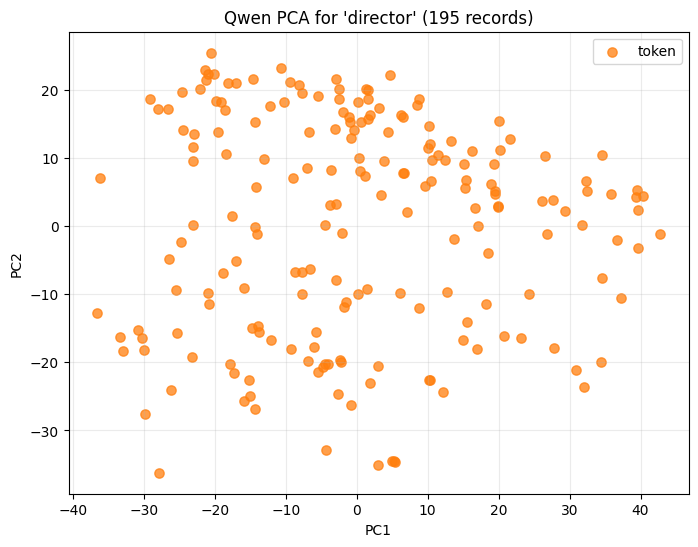

dict_keys(['records', 'embeddings', 'coords'])

In [15]:
query = "director"
query_kind = None
prompt_method = "word_context"  # or "target_marker"/"word_context"

query_embedding_result = collect_query_span_embeddings(
    embedding_store,
    query,
    kind=query_kind,
    batch_size=qwen_batch_size,
    max_length=qwen_max_length,
    prompt_method=prompt_method,
)

pca_result = plot_query_span_embeddings_pca(query_embedding_result, annotate=False)
pca_result.keys() if pca_result is not None else None
